# 09 · High-level Fusion
**Companion to the lecture:** *High-level Fusion* — Erik Blasch, FUSION Boot Camp 2026 (lecture 7).

> ⚠️ The slides for lecture 7 are **not** in the PDF, but Blasch's introduction (notebook 01) covers the foundations. 
> This notebook is based on them and on the literature (Blasch, Bossé, Lambert, *High-Level Information Fusion*).

Levels **L0/L1** (notebooks 02–05) deal with **objects**: where and what. Levels **L2–L5** deal with **meaning**: 
what the situation is, what the threat/impact is, how to task sensors (process refinement), and what the human needs (user refinement).

## A. Recap — the higher JDL/DFIG levels
| Level | Name | Question | Techniques |
|-------|------|----------|------------|
| **L2** | Situation Assessment | what are the relations among entities? | Bayesian nets, graphs, ontologies |
| **L3** | Threat / Impact | what are the consequences and intent? | game theory, abductive inference |
| **L4** | Process Refinement | how to task the sensors? | sensor management (notebook 08) |
| **L5** | User Refinement | what should the human see/decide? | HMI, visualization, explanation |

Distinguishing feature: at L2+ the inference is **abductive** (the most plausible explanation) and sometimes **soft** 
(text/human reports), unlike the quantitative/hard inference at the lower levels.

## B. Threat / Impact Assessment — a numerical example
We demonstrate **kinematic + identity** fusion for threat ranking. For each target we compute a threat score combining:
* **CPA** (Closest Point of Approach) — how close the trajectory will pass to the protected asset (kinematic, from L1).
* **TTI** (Time-To-Intercept) — when (urgency).
* **P(hostile)** — the hostility probability from classification (notebook 07).
Threat score: $\text{threat} = P(\text{hostile})\cdot f_{CPA}\cdot f_{TTI}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(4)
asset = np.array([0.,0.])    # the protected asset at the origin

def cpa_tti(pos, vel):
    """Closest Point of Approach (distance) and time to it, relative to the asset at origin."""
    r=pos-asset; v=vel
    if v@v < 1e-9: return np.linalg.norm(r), np.inf
    t=-(r@v)/(v@v); t=max(t,0.0)
    cpa=np.linalg.norm(r+v*t)
    return cpa, t

# five targets: position, velocity, hostility probability
tgts=[
  dict(name='T1', pos=np.array([100.,5.]),  vel=np.array([-10.,0.]),  p_host=0.9),
  dict(name='T2', pos=np.array([80.,80.]),  vel=np.array([-8.,-8.]),  p_host=0.5),
  dict(name='T3', pos=np.array([200.,2.]),  vel=np.array([-5.,0.]),   p_host=0.95),
  dict(name='T4', pos=np.array([30.,60.]),  vel=np.array([0.,-2.]),   p_host=0.2),
  dict(name='T5', pos=np.array([60.,3.]),   vel=np.array([-12.,0.]),  p_host=0.7),
]
for t in tgts:
    cpa,tti=cpa_tti(t['pos'],t['vel'])
    f_cpa=np.exp(-cpa/20.0)            # closer -> more dangerous
    f_tti=np.exp(-tti/15.0)            # sooner -> more urgent
    t['cpa'],t['tti'],t['threat']=cpa,tti,t['p_host']*f_cpa*f_tti

ranked=sorted(tgts,key=lambda d:-d['threat'])
print('threat ranking (L3):')
for r,t in enumerate(ranked,1):
    print(f"{r}. {t['name']}  threat={t['threat']:.3f}  CPA={t['cpa']:5.1f}  TTI={t['tti']:5.1f}  P(host)={t['p_host']}")

threat ranking (L3):
1. T5  threat=0.432  CPA=  3.0  TTI=  5.0  P(host)=0.7
2. T1  threat=0.360  CPA=  5.0  TTI= 10.0  P(host)=0.9
3. T2  threat=0.257  CPA=  0.0  TTI= 10.0  P(host)=0.5
4. T3  threat=0.060  CPA=  2.0  TTI= 40.0  P(host)=0.95
5. T4  threat=0.006  CPA= 30.0  TTI= 30.0  P(host)=0.2


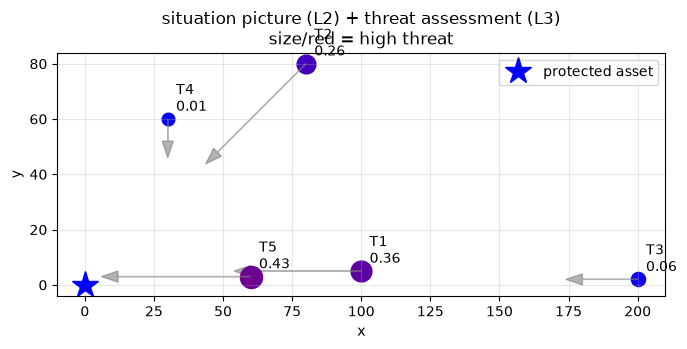

In [2]:
# visualization of the situation picture (L2) and threat ranking (L3)
plt.figure(figsize=(7,6))
plt.plot(*asset,'b*',ms=20,label='protected asset')
for t in tgts:
    p,v=t['pos'],t['vel']
    plt.scatter(*p,s=80+400*t['threat'],c=[[t['threat'],0,1-t['threat']]])
    plt.arrow(p[0],p[1],v[0]*4,v[1]*4,head_width=4,color='gray',alpha=.6)
    plt.annotate(f"{t['name']}\n{t['threat']:.2f}",p,textcoords='offset points',xytext=(6,6))
plt.title('situation picture (L2) + threat assessment (L3)\nsize/red = high threat'); plt.gca().set_aspect('equal')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## C. Evaluation measures (MOP/MOE) — the difficulty Blasch emphasized
Blasch stresses that **evaluating fusion systems is hard** (complexity, robustness, interoperability). We distinguish:
* **MOP (Measures of Performance)** — low-level technical measures: RMSE, $P_D/P_{FA}$, runtime.
* **MOE (Measures of Effectiveness)** — whether the mission was accomplished: threat-ranking accuracy, timely warning, operator load.
A common decision-quality measure: the **area under the ROC (AUC)**.

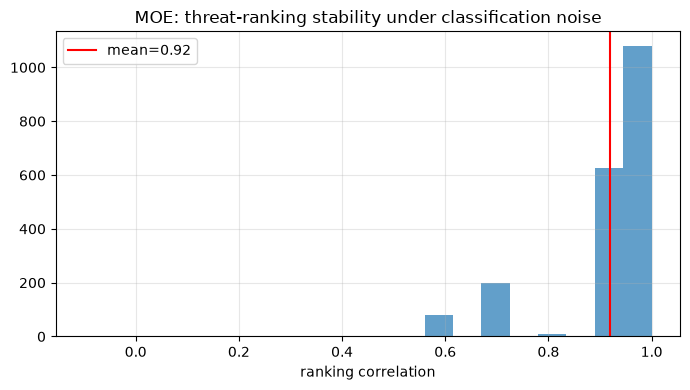

In [3]:
# MOE: does our threat ranking correlate with the 'true' threat? (Monte-Carlo with classification noise)
def trial():
    order_est=[]; order_true=[]
    for t in tgts:
        p_obs=np.clip(t['p_host']+0.2*rng.standard_normal(),0,1)  # noisy classification
        f_cpa=np.exp(-t['cpa']/20); f_tti=np.exp(-t['tti']/15)
        order_est.append(p_obs*f_cpa*f_tti)
        order_true.append(t['threat'])
    # Spearman-like: agreement of the priority ordering
    re=np.argsort(np.argsort(-np.array(order_est)))
    rt=np.argsort(np.argsort(-np.array(order_true)))
    return np.corrcoef(re,rt)[0,1]
corrs=[trial() for _ in range(2000)]
plt.figure(figsize=(7,4)); plt.hist(corrs,bins=20,alpha=.7)
plt.axvline(np.mean(corrs),color='r',label=f'mean={np.mean(corrs):.2f}')
plt.title('MOE: threat-ranking stability under classification noise'); plt.xlabel('ranking correlation'); plt.legend()
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## D. Hard + Soft Fusion and the human in the loop (L5)
High-level fusion combines **hard** sources (physical sensors) with **soft** sources (human reports, text, intelligence). 
Blasch emphasizes that fusion does **not** replace human reasoning but supports it (L5): display, explanation, and interaction. 
The open challenges he listed in the introduction: modeling **intent**, an **intelligent reactive** adversary, and the need for 
**common challenge problems** and standardized evaluation for comparison and reproducibility.

## Summary
* Levels **L2–L5** move from 'objects' to 'meaning': situation, threat, process management, and the human in the loop.
* Threat assessment combines **kinematics (CPA/TTI)** with **identity (P(hostile))** — connecting notebooks 03–07.
* Distinguish **MOP** (technical performance) from **MOE** (mission success); high-level fusion evaluation remains hard.
* The goal: **hard+soft fusion** supporting human reasoning — closing the loop back to the principles in notebook 01.